### Сбор дополнительных признаков для задачи прогнозирования

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
import requests
import os
import datetime as dt


import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

from matplotlib.transforms import blended_transform_factory

/Users/ivanandreev/Desktop/ДИПЛОМ/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
shock_date = pd.Timestamp("2022-02-01")

# Создаем папку для сохранения рисунков
save_dir = "figures/eda_block_8"
os.makedirs(save_dir, exist_ok=True)

In [3]:
def human_format(x, pos):
    """
    Красивый формат чисел на оси Y:
    1 200 000 000 -> 1.2B
    35 000 000    -> 35M
    8 000         -> 8K
    """
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


def percent_format(x, pos):
    """Формат процентов для оси Y."""
    return f"{x:.0f}%"


def apply_thesis_style(ax, title, ylabel=None, xlabel=None, highlight_post_period=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if highlight_post_period:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        ax.text(
            x_text, 0.04,
            "Постсанкционный период",
            transform=trans,
            color="#8B0000",
            fontsize=10,
            ha="right",
            va="bottom",
            linespacing=1.0
        )

def save_figure(fig, filename):
    """
    Сохраняем график сразу в PNG и PDF.
    PNG удобно вставлять в текст, PDF хорош для печати.
    """
    png_path = os.path.join(save_dir, f"{filename}.png")
    fig.savefig(png_path, dpi=400, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [4]:
data = pd.read_excel('data/final_data.xlsx')
data["rep_date"] = pd.to_datetime(data["rep_date"])
data = data.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

monthly = (
    data.groupby("rep_date", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_import_value"})
    .sort_values("rep_date")
)

monthly

,rep_date,total_import_value
0,2019-01-01,2.631455e+08
1,2019-02-01,2.988145e+08
2,2019-03-01,3.797893e+08
3,2019-04-01,3.531492e+08
4,2019-05-01,3.480698e+08
...,...,...
73,2025-02-01,3.264640e+08
74,2025-03-01,4.521075e+08
75,2025-04-01,4.324886e+08
76,2025-05-01,3.917702e+08


#### Курс рубля к доллару

In [5]:
def cbr_fx_yearly(start="01/01/2017", end="31/12/2024"):
    CBR_URL = "https://www.cbr.ru/scripts/XML_dynamic.asp"
    CODES = {"usd_rub":"R01235"}
    data = {}
    
    for curr, code in CODES.items():
        params = {"date_req1": start, "date_req2": end, "VAL_NM_RQ": code}
        r = requests.get(CBR_URL, params=params, timeout=30)
        r.raise_for_status()
        root = ET.fromstring(r.content)

        rows = []
        for rec in root.findall("Record"):
            d = rec.attrib["Date"] 
            v = rec.find("Value").text.replace(",", ".")
            rows.append((pd.to_datetime(d, dayfirst=True), float(v)))
        
        df = pd.DataFrame(rows, columns=["rep_date", curr]).set_index("rep_date")
        df = df.resample("M").mean().round(4)
        df.index = df.index.to_period('M').to_timestamp('D')
        data[curr] = df[curr]
    
    result = pd.concat(data, axis=1).reset_index().rename(columns={"index":"rep_date"})
    result['rep_date'] = result['rep_date'].dt.strftime('%Y-%m-%d').astype(str)
    result['rep_date'] = pd.to_datetime(result['rep_date'])
    return result

fx = cbr_fx_yearly(start="01/01/2019", end="30/06/2025")
fx

/var/folders/yf/82c7fyfs1m3c7t3l4p06rzp00000gn/T/ipykernel_4223/3137786941.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample("M").mean().round(4)


,rep_date,usd_rub
0,2019-01-01,66.5125
1,2019-02-01,65.8105
2,2019-03-01,65.0923
3,2019-04-01,64.6031
4,2019-05-01,64.8187
...,...,...
73,2025-02-01,92.7423
74,2025-03-01,86.0234
75,2025-04-01,83.4256
76,2025-05-01,80.2048


In [6]:
fx_plot = fx.copy()
fx_plot["rep_date"] = pd.to_datetime(fx_plot["rep_date"])

plot_df = (
    monthly.merge(fx_plot[["rep_date", "usd_rub"]], on="rep_date", how="left")
    .sort_values("rep_date")
)

plot_df

,rep_date,total_import_value,usd_rub
0,2019-01-01,2.631455e+08,66.5125
1,2019-02-01,2.988145e+08,65.8105
2,2019-03-01,3.797893e+08,65.0923
3,2019-04-01,3.531492e+08,64.6031
4,2019-05-01,3.480698e+08,64.8187
...,...,...,...
73,2025-02-01,3.264640e+08,92.7423
74,2025-03-01,4.521075e+08,86.0234
75,2025-04-01,4.324886e+08,83.4256
76,2025-05-01,3.917702e+08,80.2048


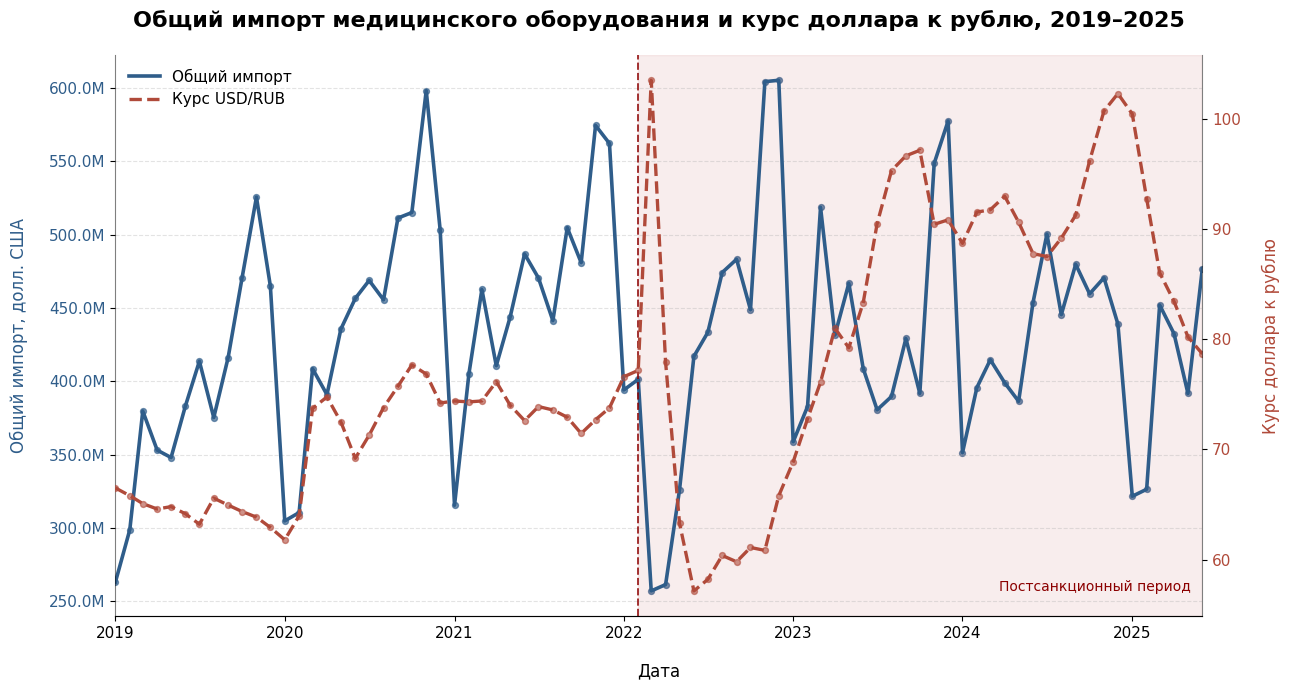

In [7]:
# График: импорт + курс USD/RUB
fig, ax1 = plt.subplots(figsize=(13, 7))

# Левая ось: импорт
line1 = ax1.plot(
    plot_df["rep_date"],
    plot_df["total_import_value"],
    color="#2F5D8A",
    linewidth=2.6,
    label="Общий импорт"
)

ax1.scatter(
    plot_df["rep_date"],
    plot_df["total_import_value"],
    color="#2F5D8A",
    s=18,
    alpha=0.65
)

ax1.yaxis.set_major_formatter(FuncFormatter(human_format))
ax1.set_ylabel("Общий импорт, долл. США", fontsize=12, labelpad=15, color="#2F5D8A")
ax1.tick_params(axis="y", labelcolor="#2F5D8A")

# Правая ось: курс доллара
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df["rep_date"],
    plot_df["usd_rub"],
    color="#B04A3A",
    linewidth=2.4,
    linestyle="--",
    label="Курс USD/RUB"
)

ax2.scatter(
    plot_df["rep_date"],
    plot_df["usd_rub"],
    color="#B04A3A",
    s=18,
    alpha=0.60
)

ax2.set_ylabel("Курс доллара к рублю", fontsize=12, labelpad=15, color="#B04A3A")
ax2.tick_params(axis="y", labelcolor="#B04A3A")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}"))

# Оформление
ax1.set_title(
    "Общий импорт медицинского оборудования и курс доллара к рублю, 2019–2025",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax1.set_xlabel("Дата", fontsize=12, labelpad=15)

ax1.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_alpha(0.5)
ax1.spines["bottom"].set_alpha(0.5)

ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_alpha(0.5)

ax1.tick_params(axis="both", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)

# ось X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# жестко задаем границы по данным, чтобы не было пустого хвоста справа
x_min = plot_df["rep_date"].min()
x_max = plot_df["rep_date"].max()
ax1.set_xlim(x_min, x_max)

# постсанкционный период
x_left = shock_date
ax1.axvspan(x_left, x_max, alpha=0.08, color="#B22222")
ax1.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

trans = blended_transform_factory(ax1.transData, ax1.transAxes)
x_text = x_max - pd.Timedelta(days=25)

ax1.text(
    x_text, 0.04,
    "Постсанкционный период",
    transform=trans,
    color="#8B0000",
    fontsize=10,
    ha="right",
    va="bottom"
)

# общая легенда
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "import_and_usd_rub_one_chart")

#### Общий ряд импорта от ЦБ

In [8]:
def make_real() -> pd.Series:
    real = pd.read_excel("./data/real.xls")
    real = real.iloc[6:]
    real = real[[real.columns[0], real.columns[8]]].dropna()
    real.columns = ['rep_date', 'cb_full_import_value']
    real['month'] = real.groupby('rep_date').cumcount() + 1
    real['rep_date'] = pd.to_datetime(
        real['rep_date'].astype(str) + '-' + real['month'].astype(str).str.zfill(2),
        format="%Y-%m"
    )
    real = real[real['rep_date'].dt.date >= dt.date(2019, 1, 1)]
    real = real[real['rep_date'].dt.date <= dt.date(2025, 6, 1)]
    real = real.drop(columns='month')
    real['cb_full_import_value'] = real['cb_full_import_value'].astype(float) * 1e6
    real['rep_date'] = pd.to_datetime(real['rep_date'])
    return real 

real = make_real()
real

,rep_date,cb_full_import_value
270,2019-01-01,1.636900e+10
271,2019-02-01,1.818200e+10
272,2019-03-01,2.090600e+10
273,2019-04-01,2.202000e+10
274,2019-05-01,1.985600e+10
...,...,...
343,2025-02-01,2.075100e+10
344,2025-03-01,2.280800e+10
345,2025-04-01,2.476300e+10
346,2025-05-01,2.434400e+10


In [9]:
real_plot = real.copy()
real_plot["rep_date"] = pd.to_datetime(real_plot["rep_date"])

plot_df_real = (
    monthly.merge(real_plot[["rep_date", "cb_full_import_value"]], on="rep_date", how="left")
    .sort_values("rep_date")
)

plot_df_real

,rep_date,total_import_value,cb_full_import_value
0,2019-01-01,2.631455e+08,1.636900e+10
1,2019-02-01,2.988145e+08,1.818200e+10
2,2019-03-01,3.797893e+08,2.090600e+10
3,2019-04-01,3.531492e+08,2.202000e+10
4,2019-05-01,3.480698e+08,1.985600e+10
...,...,...,...
73,2025-02-01,3.264640e+08,2.075100e+10
74,2025-03-01,4.521075e+08,2.280800e+10
75,2025-04-01,4.324886e+08,2.476300e+10
76,2025-05-01,3.917702e+08,2.434400e+10


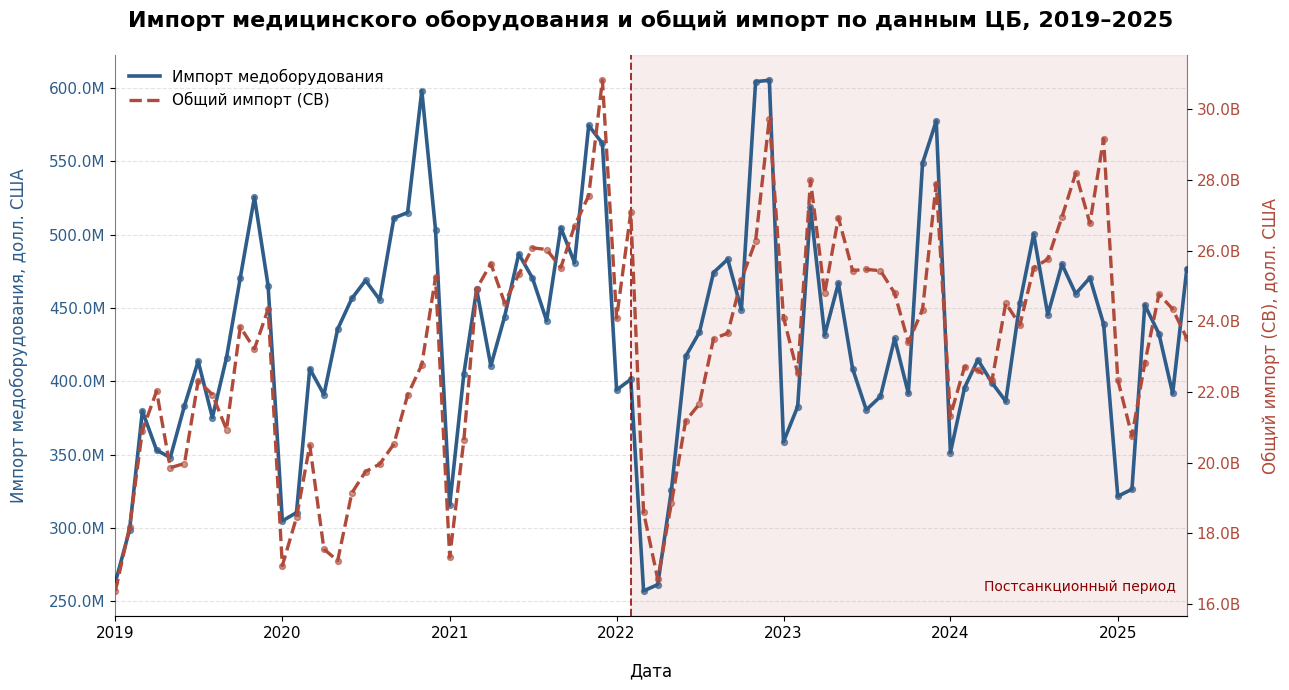

In [10]:
# График: импорт медоборудования + cb_full_import_value

fig, ax1 = plt.subplots(figsize=(13, 7))

# Левая ось: импорт медоборудования
line1 = ax1.plot(
    plot_df_real["rep_date"],
    plot_df_real["total_import_value"],
    color="#2F5D8A",
    linewidth=2.6,
    label="Импорт медоборудования"
)

ax1.scatter(
    plot_df_real["rep_date"],
    plot_df_real["total_import_value"],
    color="#2F5D8A",
    s=18,
    alpha=0.65
)

ax1.yaxis.set_major_formatter(FuncFormatter(human_format))
ax1.set_ylabel("Импорт медоборудования, долл. США", fontsize=12, labelpad=15, color="#2F5D8A")
ax1.tick_params(axis="y", labelcolor="#2F5D8A")

# Правая ось: cb_full_import_value
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df_real["rep_date"],
    plot_df_real["cb_full_import_value"],
    color="#B04A3A",
    linewidth=2.4,
    linestyle="--",
    label="Общий импорт (CB)"
)

ax2.scatter(
    plot_df_real["rep_date"],
    plot_df_real["cb_full_import_value"],
    color="#B04A3A",
    s=18,
    alpha=0.60
)

ax2.yaxis.set_major_formatter(FuncFormatter(human_format))
ax2.set_ylabel("Общий импорт (CB), долл. США", fontsize=12, labelpad=15, color="#B04A3A")
ax2.tick_params(axis="y", labelcolor="#B04A3A")

# Оформление
ax1.set_title(
    "Импорт медицинского оборудования и общий импорт по данным ЦБ, 2019–2025",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax1.set_xlabel("Дата", fontsize=12, labelpad=15)

ax1.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_alpha(0.5)
ax1.spines["bottom"].set_alpha(0.5)

ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_alpha(0.5)

ax1.tick_params(axis="both", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)

# Ось X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Жесткие границы по реальным данным
x_min = plot_df_real["rep_date"].min()
x_max = plot_df_real["rep_date"].max()
ax1.set_xlim(x_min, x_max)

# Постсанкционный период
ax1.axvspan(shock_date, x_max, alpha=0.08, color="#B22222")
ax1.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

trans = blended_transform_factory(ax1.transData, ax1.transAxes)
x_text = x_max - pd.Timedelta(days=25)

ax1.text(
    x_text, 0.04,
    "Постсанкционный период",
    transform=trans,
    color="#8B0000",
    fontsize=10,
    ha="right",
    va="bottom"
)

# Общая легенда
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "import_and_cb_full_import_one_chart")

#### Общий ряд НДС на ввозимые товары

In [13]:
def make_nds():
    nds = pd.read_excel("data/gov_earn_expendings.xlsx")
    nds.columns = nds.iloc[1]
    nds = nds[nds[nds.columns[1]] == "НДС на ввозимые товары"].iloc[:, 2:]
    nds = pd.melt(nds)
    nds.columns = ["month", "gov_earn_from_import_nds"]
    
    map_fix = {
        "янв.23 ***": dt.datetime(2023, 1, 1),
        "фев.23 ***": dt.datetime(2023, 2, 1),
        "апр.24 ***": dt.datetime(2024, 4, 1),
        "июн.24 ***": dt.datetime(2024, 6, 1),
        "сен.24 ***": dt.datetime(2024, 9, 1),
        "ноя.24 ***": dt.datetime(2024, 11, 1),
        "фев.25 ***": dt.datetime(2025, 2, 1),
        "июн.25 ***": dt.datetime(2025, 6, 1),
        "июл.25 **":  dt.datetime(2025, 7, 1),
        "авг.25 **":  dt.datetime(2025, 8, 1),
    }
    nds['month'] = pd.to_datetime(nds['month'].replace(map_fix), errors="coerce")
    nds['value'] = nds.groupby(nds['month'].dt.year)['gov_earn_from_import_nds'].diff()
    nds.loc[nds['month'].dt.month == 1, 'value'] = nds.loc[nds['month'].dt.month == 1, 'gov_earn_from_import_nds']
    nds = nds.drop(columns='gov_earn_from_import_nds')
    nds = nds.rename(columns={'month': 'rep_date', 'value': 'gov_earn_from_import_nds'})
    nds['gov_earn_from_import_nds'] = nds['gov_earn_from_import_nds'].astype(float) * 1e9
    nds['rep_date'] = pd.to_datetime(nds['rep_date'])
    return nds

nds = make_nds()
nds

/var/folders/yf/82c7fyfs1m3c7t3l4p06rzp00000gn/T/ipykernel_4223/1729251515.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nds['month'] = pd.to_datetime(nds['month'].replace(map_fix), errors="coerce")


,rep_date,gov_earn_from_import_nds
0,2011-01-01,6.741335e+10
1,2011-02-01,9.867449e+10
2,2011-03-01,1.271080e+11
3,2011-04-01,1.211507e+11
4,2011-05-01,1.259846e+11
...,...,...
171,2025-04-01,3.348197e+11
172,2025-05-01,3.208419e+11
173,2025-06-01,3.028968e+11
174,2025-07-01,3.354463e+11


In [14]:
nds = nds.merge(fx, on='rep_date', how='inner')
nds['gov_earn_from_import_nds'] = nds['gov_earn_from_import_nds'] / nds['usd_rub']
nds = nds.drop(columns='usd_rub')
nds

,rep_date,gov_earn_from_import_nds
0,2019-01-01,2.670099e+09
1,2019-02-01,3.180006e+09
2,2019-03-01,3.444307e+09
3,2019-04-01,3.732597e+09
4,2019-05-01,3.551520e+09
...,...,...
73,2025-02-01,3.572410e+09
74,2025-03-01,3.836182e+09
75,2025-04-01,4.013393e+09
76,2025-05-01,4.000284e+09


In [15]:
nds_plot = nds.copy()
nds_plot["rep_date"] = pd.to_datetime(nds_plot["rep_date"])

plot_df_nds = (
    monthly.merge(nds_plot[["rep_date", "gov_earn_from_import_nds"]], on="rep_date", how="left")
    .sort_values("rep_date")
)

plot_df_nds

,rep_date,total_import_value,gov_earn_from_import_nds
0,2019-01-01,2.631455e+08,2.670099e+09
1,2019-02-01,2.988145e+08,3.180006e+09
2,2019-03-01,3.797893e+08,3.444307e+09
3,2019-04-01,3.531492e+08,3.732597e+09
4,2019-05-01,3.480698e+08,3.551520e+09
...,...,...,...
73,2025-02-01,3.264640e+08,3.572410e+09
74,2025-03-01,4.521075e+08,3.836182e+09
75,2025-04-01,4.324886e+08,4.013393e+09
76,2025-05-01,3.917702e+08,4.000284e+09


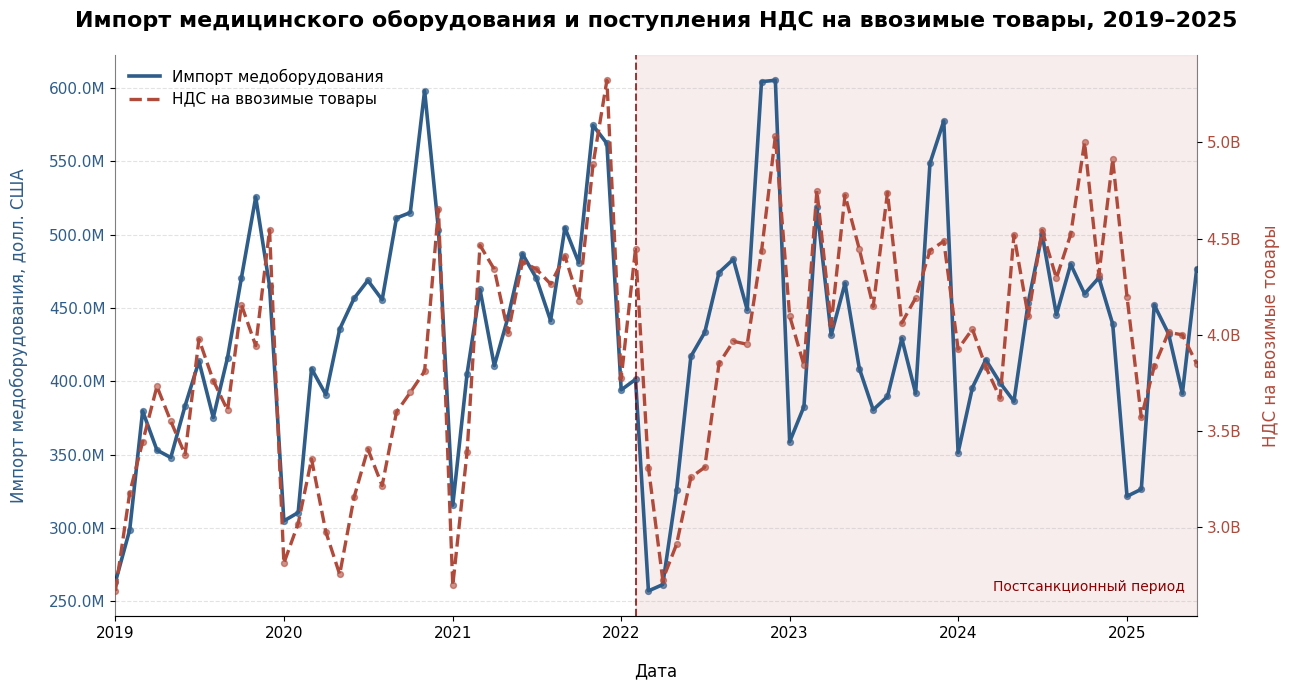

In [16]:
# График: импорт медоборудования + НДС на ввозимые товары

fig, ax1 = plt.subplots(figsize=(13, 7))

# Левая ось: импорт медоборудования
line1 = ax1.plot(
    plot_df_nds["rep_date"],
    plot_df_nds["total_import_value"],
    color="#2F5D8A",
    linewidth=2.6,
    label="Импорт медоборудования"
)

ax1.scatter(
    plot_df_nds["rep_date"],
    plot_df_nds["total_import_value"],
    color="#2F5D8A",
    s=18,
    alpha=0.65
)

ax1.yaxis.set_major_formatter(FuncFormatter(human_format))
ax1.set_ylabel("Импорт медоборудования, долл. США", fontsize=12, labelpad=15, color="#2F5D8A")
ax1.tick_params(axis="y", labelcolor="#2F5D8A")

# Правая ось: НДС на ввозимые товары
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df_nds["rep_date"],
    plot_df_nds["gov_earn_from_import_nds"],
    color="#B04A3A",
    linewidth=2.4,
    linestyle="--",
    label="НДС на ввозимые товары"
)

ax2.scatter(
    plot_df_nds["rep_date"],
    plot_df_nds["gov_earn_from_import_nds"],
    color="#B04A3A",
    s=18,
    alpha=0.60
)

ax2.yaxis.set_major_formatter(FuncFormatter(human_format))
ax2.set_ylabel("НДС на ввозимые товары", fontsize=12, labelpad=15, color="#B04A3A")
ax2.tick_params(axis="y", labelcolor="#B04A3A")

# Оформление
ax1.set_title(
    "Импорт медицинского оборудования и поступления НДС на ввозимые товары, 2019–2025",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax1.set_xlabel("Дата", fontsize=12, labelpad=15)

ax1.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_alpha(0.5)
ax1.spines["bottom"].set_alpha(0.5)

ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_alpha(0.5)

ax1.tick_params(axis="both", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)

# Ось X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Реальные границы
x_min = plot_df_nds["rep_date"].min()
x_max = plot_df_nds["rep_date"].max()
ax1.set_xlim(x_min, x_max)

# Постсанкционный период
ax1.axvspan(shock_date, x_max, alpha=0.08, color="#B22222")
ax1.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

trans = blended_transform_factory(ax1.transData, ax1.transAxes)
x_text = x_max - pd.Timedelta(days=25)

ax1.text(
    x_text, 0.04,
    "Постсанкционный период",
    transform=trans,
    color="#8B0000",
    fontsize=10,
    ha="right",
    va="bottom"
)

# Общая легенда
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "import_and_import_vat_one_chart")

#### Общий ряд государственных расходов

In [17]:
def make_gov_exp():
    gov_exp = pd.read_excel("data/gov_earn_expendings.xlsx")
    gov_exp.columns = gov_exp.iloc[1]
    gov_exp = gov_exp[gov_exp[gov_exp.columns[1]] == "Расходы, всего"].iloc[:, 2:]
    gov_exp = pd.melt(gov_exp)
    gov_exp.columns = ["month", "gov_expendings"]
    
    map_fix = {
        "янв.23 ***": dt.datetime(2023, 1, 1),
        "фев.23 ***": dt.datetime(2023, 2, 1),
        "апр.24 ***": dt.datetime(2024, 4, 1),
        "июн.24 ***": dt.datetime(2024, 6, 1),
        "сен.24 ***": dt.datetime(2024, 9, 1),
        "ноя.24 ***": dt.datetime(2024, 11, 1),
        "фев.25 ***": dt.datetime(2025, 2, 1),
        "июн.25 ***": dt.datetime(2025, 6, 1),
        "июл.25 **":  dt.datetime(2025, 7, 1),
        "авг.25 **":  dt.datetime(2025, 8, 1),
    }
    gov_exp['month'] = pd.to_datetime(gov_exp['month'].replace(map_fix), errors="coerce")
    gov_exp['value'] = gov_exp.groupby(gov_exp['month'].dt.year)['gov_expendings'].diff()
    gov_exp.loc[gov_exp['month'].dt.month == 1, 'value'] = gov_exp.loc[gov_exp['month'].dt.month == 1, 'gov_expendings']
    gov_exp = gov_exp.drop(columns='gov_expendings')
    gov_exp = gov_exp.rename(columns={'month': 'rep_date', 'value': 'gov_expendings'})
    gov_exp['gov_expendings'] = gov_exp['gov_expendings'].astype(float) * 1e9
    return gov_exp

gov_exp = make_gov_exp()
gov_exp

/var/folders/yf/82c7fyfs1m3c7t3l4p06rzp00000gn/T/ipykernel_4223/63333441.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gov_exp['month'] = pd.to_datetime(gov_exp['month'].replace(map_fix), errors="coerce")


,rep_date,gov_expendings
0,2011-01-01,6.573728e+11
1,2011-02-01,7.697523e+11
2,2011-03-01,7.876183e+11
3,2011-04-01,9.618640e+11
4,2011-05-01,6.381661e+11
...,...,...
171,2025-04-01,4.195221e+12
172,2025-05-01,2.559242e+12
173,2025-06-01,3.211377e+12
174,2025-07-01,3.968298e+12


In [18]:
gov_exp = gov_exp.merge(fx, on='rep_date', how='inner')
gov_exp['gov_expendings'] = gov_exp['gov_expendings'] / gov_exp['usd_rub']
gov_exp = gov_exp.drop(columns='usd_rub')
gov_exp

,rep_date,gov_expendings
0,2019-01-01,1.683345e+10
1,2019-02-01,2.044704e+10
2,2019-03-01,2.241134e+10
3,2019-04-01,2.509582e+10
4,2019-05-01,1.602645e+10
...,...,...
73,2025-02-01,3.908616e+10
74,2025-03-01,3.779737e+10
75,2025-04-01,5.028698e+10
76,2025-05-01,3.190884e+10


In [19]:
gov_exp_plot = gov_exp.copy()
gov_exp_plot["rep_date"] = pd.to_datetime(gov_exp_plot["rep_date"])

plot_df_govexp = (
    monthly.merge(gov_exp_plot[["rep_date", "gov_expendings"]], on="rep_date", how="left")
    .sort_values("rep_date")
)

plot_df_govexp

,rep_date,total_import_value,gov_expendings
0,2019-01-01,2.631455e+08,1.683345e+10
1,2019-02-01,2.988145e+08,2.044704e+10
2,2019-03-01,3.797893e+08,2.241134e+10
3,2019-04-01,3.531492e+08,2.509582e+10
4,2019-05-01,3.480698e+08,1.602645e+10
...,...,...,...
73,2025-02-01,3.264640e+08,3.908616e+10
74,2025-03-01,4.521075e+08,3.779737e+10
75,2025-04-01,4.324886e+08,5.028698e+10
76,2025-05-01,3.917702e+08,3.190884e+10


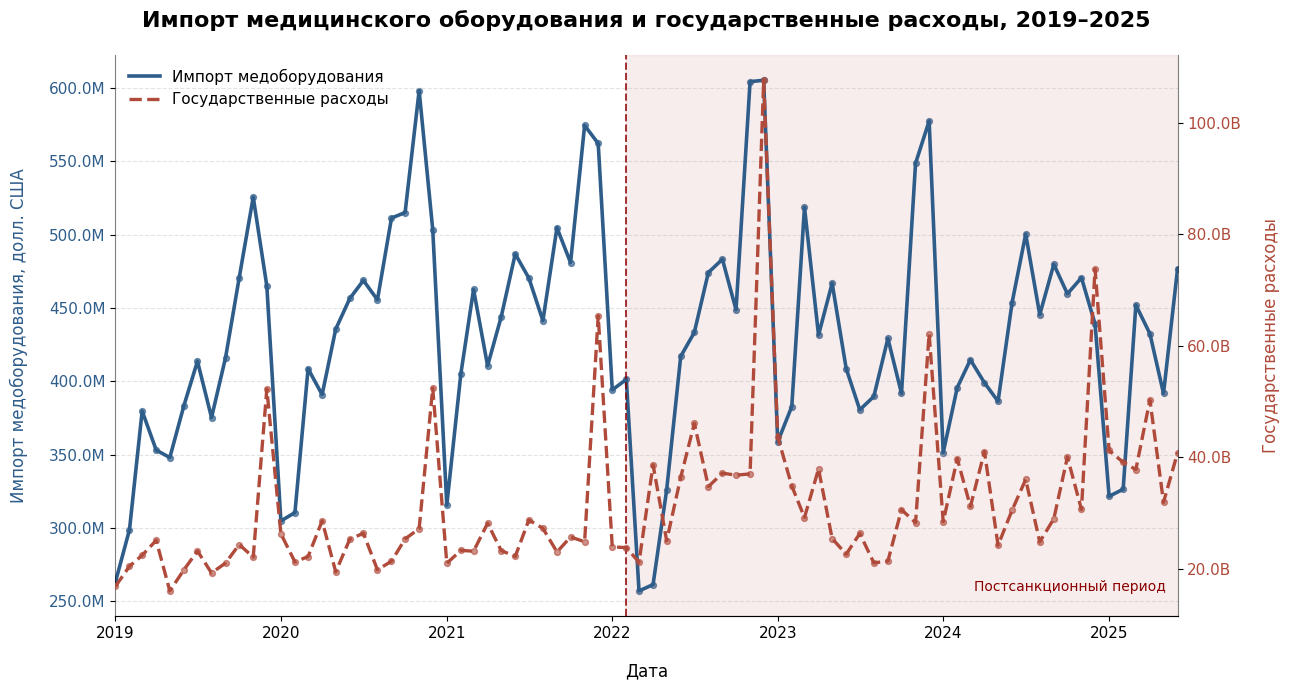

In [20]:
# График: импорт медоборудования + госрасходы

fig, ax1 = plt.subplots(figsize=(13, 7))

# Левая ось: импорт медоборудования
line1 = ax1.plot(
    plot_df_govexp["rep_date"],
    plot_df_govexp["total_import_value"],
    color="#2F5D8A",
    linewidth=2.6,
    label="Импорт медоборудования"
)

ax1.scatter(
    plot_df_govexp["rep_date"],
    plot_df_govexp["total_import_value"],
    color="#2F5D8A",
    s=18,
    alpha=0.65
)

ax1.yaxis.set_major_formatter(FuncFormatter(human_format))
ax1.set_ylabel("Импорт медоборудования, долл. США", fontsize=12, labelpad=15, color="#2F5D8A")
ax1.tick_params(axis="y", labelcolor="#2F5D8A")

# Правая ось: государственные расходы
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df_govexp["rep_date"],
    plot_df_govexp["gov_expendings"],
    color="#B04A3A",
    linewidth=2.4,
    linestyle="--",
    label="Государственные расходы"
)

ax2.scatter(
    plot_df_govexp["rep_date"],
    plot_df_govexp["gov_expendings"],
    color="#B04A3A",
    s=18,
    alpha=0.60
)

ax2.yaxis.set_major_formatter(FuncFormatter(human_format))
ax2.set_ylabel("Государственные расходы", fontsize=12, labelpad=15, color="#B04A3A")
ax2.tick_params(axis="y", labelcolor="#B04A3A")

# Оформление
ax1.set_title(
    "Импорт медицинского оборудования и государственные расходы, 2019–2025",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax1.set_xlabel("Дата", fontsize=12, labelpad=15)

ax1.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_alpha(0.5)
ax1.spines["bottom"].set_alpha(0.5)

ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_alpha(0.5)

ax1.tick_params(axis="both", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)

# Ось X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Реальные границы
x_min = plot_df_govexp["rep_date"].min()
x_max = plot_df_govexp["rep_date"].max()
ax1.set_xlim(x_min, x_max)

# Постсанкционный период
ax1.axvspan(shock_date, x_max, alpha=0.08, color="#B22222")
ax1.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

trans = blended_transform_factory(ax1.transData, ax1.transAxes)
x_text = x_max - pd.Timedelta(days=25)

ax1.text(
    x_text, 0.04,
    "Постсанкционный период",
    transform=trans,
    color="#8B0000",
    fontsize=10,
    ha="right",
    va="bottom"
)

# Общая легенда
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "import_and_gov_expendings_one_chart")

#### Объединение

In [21]:
data

,rep_date,country,hs,value,sanctions_proxy,sanctions_proxy_smooth,cpi_yoy,ip_yoy,ex_yoy,gscpi,distw,logistics_exposure_distw,unfriendly,brics,cis,post_sanctions,unfriendly_post,brics_post,cis_post
0,2019-01-01,Albania,9018,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,2777.355,4.086917,1,0,0,0,0,0,0
1,2019-01-01,Albania,9019,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,2777.355,4.086917,1,0,0,0,0,0,0
2,2019-01-01,Albania,9020,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,2777.355,4.086917,1,0,0,0,0,0,0
3,2019-01-01,Albania,9021,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,2777.355,4.086917,1,0,0,0,0,0,0
4,2019-01-01,Albania,9022,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,2777.355,4.086917,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48433,2025-06-01,Uzbekistan,9022,0.0,0,0,8.494769,7.483273,0.581069,0.084302,2528.859,0.660547,0,0,1,1,0,0,1
48434,2025-06-01,Uzbekistan,9025,0.0,0,0,8.494769,7.483273,0.581069,0.084302,2528.859,0.660547,0,0,1,1,0,0,1
48435,2025-06-01,Uzbekistan,9027,0.0,0,0,8.494769,7.483273,0.581069,0.084302,2528.859,0.660547,0,0,1,1,0,0,1
48436,2025-06-01,Uzbekistan,9030,0.0,0,0,8.494769,7.483273,0.581069,0.084302,2528.859,0.660547,0,0,1,1,0,0,1


In [ ]:
rea

,rep_date,gov_earn_from_import_nds
0,2019-01-01,2.670099e+09
1,2019-02-01,3.180006e+09
2,2019-03-01,3.444307e+09
3,2019-04-01,3.732597e+09
4,2019-05-01,3.551520e+09
...,...,...
73,2025-02-01,3.572410e+09
74,2025-03-01,3.836182e+09
75,2025-04-01,4.013393e+09
76,2025-05-01,4.000284e+09


In [23]:
final_data = data.merge(real, on='rep_date', how='inner')
final_data = final_data.merge(fx, on='rep_date', how='inner')
final_data = final_data.merge(nds, on='rep_date', how='inner')
final_data = final_data.merge(gov_exp, on='rep_date', how='inner')
final_data

,rep_date,country,hs,value,sanctions_proxy,sanctions_proxy_smooth,cpi_yoy,ip_yoy,ex_yoy,gscpi,...,brics,cis,post_sanctions,unfriendly_post,brics_post,cis_post,cb_full_import_value,usd_rub,gov_earn_from_import_nds,gov_expendings
0,2019-01-01,Albania,9018,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,...,0,0,0,0,0,0,1.636900e+10,66.5125,2.670099e+09,1.683345e+10
1,2019-01-01,Albania,9019,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,...,0,0,0,0,0,0,1.636900e+10,66.5125,2.670099e+09,1.683345e+10
2,2019-01-01,Albania,9020,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,...,0,0,0,0,0,0,1.636900e+10,66.5125,2.670099e+09,1.683345e+10
3,2019-01-01,Albania,9021,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,...,0,0,0,0,0,0,1.636900e+10,66.5125,2.670099e+09,1.683345e+10
4,2019-01-01,Albania,9022,0.0,0,0,1.930000,5.800000,-0.163976,0.515423,...,0,0,0,0,0,0,1.636900e+10,66.5125,2.670099e+09,1.683345e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48433,2025-06-01,Uzbekistan,9022,0.0,0,0,8.494769,7.483273,0.581069,0.084302,...,0,1,1,0,0,1,2.351200e+10,78.6679,3.850323e+09,4.082195e+10
48434,2025-06-01,Uzbekistan,9025,0.0,0,0,8.494769,7.483273,0.581069,0.084302,...,0,1,1,0,0,1,2.351200e+10,78.6679,3.850323e+09,4.082195e+10
48435,2025-06-01,Uzbekistan,9027,0.0,0,0,8.494769,7.483273,0.581069,0.084302,...,0,1,1,0,0,1,2.351200e+10,78.6679,3.850323e+09,4.082195e+10
48436,2025-06-01,Uzbekistan,9030,0.0,0,0,8.494769,7.483273,0.581069,0.084302,...,0,1,1,0,0,1,2.351200e+10,78.6679,3.850323e+09,4.082195e+10


In [24]:
final_data.columns

Index(['rep_date', 'country', 'hs', 'value', 'sanctions_proxy',
       'sanctions_proxy_smooth', 'cpi_yoy', 'ip_yoy', 'ex_yoy', 'gscpi',
       'distw', 'logistics_exposure_distw', 'unfriendly', 'brics', 'cis',
       'post_sanctions', 'unfriendly_post', 'brics_post', 'cis_post',
       'cb_full_import_value', 'usd_rub', 'gov_earn_from_import_nds',
       'gov_expendings'],
      dtype='object')

In [26]:
final_data.to_excel('data/final_forecasting_data.xlsx', index=False)